# Intro PyTorch: regresión lineal desde cero (réplica)

Objetivo: reconstruir el notebook original pieza por pieza, verificando formas y valores en cada paso.

Plan:
1. Datos sintéticos
2. Forward como función suelta
3. Pérdida y gradiente a mano
4. Un paso de SGD manual y bucle simple
5. Clases `SGD` y `LinearRegression`
6. Minibatches y validación (`TensorDataset`, `DataLoader`)
7. Bucle de entrenamiento completo y gráfica

## 1. Datos sintéticos

**Qué espero:** `X` de forma `(1000, 2)` y `y` de forma `(1000, 1)`, con `y ≈ X @ true_w + true_b`.

Revisar: `.shape`, primeras filas, y la diferencia `y - (X @ w + b)` (debería ser solo ruido).

In [1]:
import torch

# TODO: definir synthetic_regression_data(w, b, num_samples=1000)

# Crear datos sintéticos para probar la infraestructura: 

def synthetic_regression_data(w, b, num_samples = 1000):
    num_inputs = w.shape[0]
    X = torch.randn(num_samples, num_inputs)
    y = X @ w.reshape(-1,1) + b
    y += torch.randn_like(y) * 0.01
    return X, y

    


In [2]:
# TODO: generar X, y con true_w = [2.0, -3.4], true_b = 4.2 e inspeccionar shapes y valores
true_w = torch.tensor([2.0, -3.4, -9.0, 2.5, 1.0])
true_b = 4.2
X, y = synthetic_regression_data(true_w, true_b)

In [3]:
X.shape


torch.Size([1000, 5])

In [4]:
y.shape

torch.Size([1000, 1])

## 2. Forward como función suelta

**Qué espero:** con `w` de forma `(2, 1)` y `b` de forma `(1,)`, `X @ w + b` da `(1000, 1)`. Observar cómo el broadcasting expande `b`.

In [5]:
# TODO: inicializar w (torch.normal) y b (torch.zeros) con requires_grad=True
# TODO: calcular y_hat = X @ w + b y revisar shapes
import torch.nn as nn

w = nn.Parameter(torch.normal(0.0, 0.01, size=(X.shape[1], 1), requires_grad=True)) ## inicializamos en 0 porque es una regresión lineal y la función de perdida es convexa, entonces siempre ecncontraremos el minimo global)
b = nn.Parameter(torch.zeros(1))

def forward(X, w, b):
    """ Calcula la estimación y_hat dados los paramétros actuales y X"""
    return torch.matmul(X, w) + b

y_hat = forward(X, w, b)



In [6]:
print(w.shape)

print(b.shape)

print(X.shape)

print(y_hat.shape)

torch.Size([5, 1])
torch.Size([1])
torch.Size([1000, 5])
torch.Size([1000, 1])


In [7]:
y_hat

tensor([[ 0.0041],
        [-0.0261],
        [ 0.0084],
        [ 0.0402],
        [ 0.0283],
        [-0.0767],
        [-0.0422],
        [ 0.0471],
        [ 0.0096],
        [-0.0005],
        [ 0.0265],
        [ 0.0046],
        [ 0.0298],
        [ 0.0022],
        [-0.0626],
        [-0.0134],
        [-0.0045],
        [-0.0170],
        [ 0.0486],
        [-0.0525],
        [-0.0123],
        [-0.0176],
        [-0.0067],
        [-0.0015],
        [ 0.0359],
        [-0.0360],
        [ 0.0142],
        [ 0.0304],
        [ 0.0139],
        [ 0.0480],
        [ 0.0103],
        [ 0.0381],
        [ 0.0155],
        [ 0.0631],
        [ 0.0324],
        [-0.0398],
        [ 0.0255],
        [ 0.0137],
        [ 0.0582],
        [-0.0262],
        [-0.0188],
        [-0.0088],
        [ 0.0546],
        [ 0.0075],
        [ 0.0172],
        [-0.0541],
        [ 0.0073],
        [ 0.0428],
        [ 0.0131],
        [ 0.0247],
        [ 0.0259],
        [-0.0401],
        [-0.

## 3. Pérdida y gradiente a mano

**Qué espero:** `loss.backward()` llena `w.grad` (forma `(2, 1)`) y `b.grad` (forma `(1,)`).

Pregunta: ¿por qué el gradiente apunta hacia donde la pérdida *sube*, y por eso restamos?

In [8]:
# TODO: loss = ((y_hat - y) ** 2 / 2).mean()
# TODO: loss.backward() e inspeccionar w.grad, b.grad

def loss(y_hat, y):
    """Calcula la pérdida de regresión lineal
    y devuelve el valor medio sobre el minibatch.
    """
    # 1) Error al cuadrado, escalado por 1/2
    l = (y_hat - y) ** 2 / 2
    # 2) Promedio sobre todas las muestras
    return l.mean()

loss_c = loss(y_hat, y)

loss_c.backward()



In [9]:
loss_c.item()

61.74887466430664

In [10]:
b.grad

tensor([-3.9514])

## 4. Un paso de SGD manual y bucle simple

**Qué espero:** tras `w.data -= lr * w.grad`, la pérdida baja. Repetir en un bucle con todos los datos (sin `DataLoader`) y ver la pérdida decrecer.

Recordar limpiar los gradientes en cada iteración.

In [11]:
# TODO: un solo paso de SGD y recalcular la pérdida

lr = 0.03

w.data -= lr * w.grad

b.data -= lr * b.grad

y_hat = forward(X, w, b)

loss_c4 = loss(y_hat, y)

loss_c4.item()


58.019752502441406

In [12]:
# TODO: bucle de varias iteraciones con todos los datos, imprimiendo la pérdida

params = [w, b]

def zero_grad(params):
    """Pone en cero los gradientes acumulados."""
    for p in params:
        if p.grad is not None:
            p.grad.zero_()

def step(params, lr):
    """Actualiza cada parámetro: θ ← θ − lr * ∇θ."""
    for p in params:
        p.data -= lr * p.grad

num_iters = 100
for i in range(num_iters):
    y_hat = forward(X, w, b)       # 1) predicción con los pesos actuales (w, b sin .data)
    loss_i = loss(y_hat, y)        # 2) pérdida -> crea un grafo nuevo
    zero_grad(params)              # 3) limpia los gradientes de la iteración anterior
    loss_i.backward()              # 4) gradientes nuevos en w.grad y b.grad
    step(params, lr)               # 5) mueve w y b en contra del gradiente
    if i % 30 == 0 or i == num_iters - 1:
        print(f"iter {i:3d} | pérdida {loss_i.item():.6f}")  # 6) monitorear

print("w aprendido:", w.data.reshape(-1))
print("b aprendido:", b.data)

    

iter   0 | pérdida 58.019753
iter  30 | pérdida 8.971306
iter  60 | pérdida 1.392652
iter  90 | pérdida 0.217081
iter  99 | pérdida 0.124407
w aprendido: tensor([ 1.9144, -3.2684, -8.6225,  2.3983,  0.9595])
b aprendido: tensor([3.9717])


## 5. Clases `SGD` y `LinearRegression`

Cada método es algo que ya escribiste suelto arriba:
- `SGD.step` / `SGD.zero_grad` ← pasos 3 y 4
- `LinearRegression.forward` ← paso 2
- `LinearRegression.loss` ← paso 3
- `LinearRegression.configure_optimizers` devuelve un `SGD`

In [13]:
# TODO: class SGD

class SGD: 
    """Descenso de gradiente estocástico por minibatches"""

    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr

    def step(self):
        """Actualiza cada parámetro: θ ← θ − lr * ∇θ."""
        for p in self.params:
            p.data -= self.lr * p.grad

    def zero_grad(self):
        """Pone a cero todos los gradientes para la siguiente iteración"""

        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


In [14]:
import torch.nn as nn

# TODO: class LinearRegression(nn.Module)

class LinearRegression(nn.Module):
    """Modelo de regresión lineal implementado desde cero"""

    def __init__(self, num_inputs, lr, sigma = 0.01):
        super(LinearRegression, self).__init__()

        self.num_inputs = num_inputs
        self.lr = lr
        self.sigma = sigma 

        self.w = nn.Parameter(
            torch.normal(0.0, sigma, size = (num_inputs, 1))
        )
        self.b = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, X):
        """Calcular y_hat usando los datos sintéticos y los pesos (w)"""
        return torch.matmul(X, self.w) + self.b

    def loss(self, y_hat, y):
        """Calcula la pérdida, definida por la diferencia entre y_hat - y al cuadrado y todo entre dos"""

        l = (y_hat - y)**2 / 2

        return l.mean()

    def configure_optimizers(self):
        """Crea y devuelve el optimizador SGD"""

        return SGD([self.w, self.b], self.lr)

## 6. Minibatches y validación

**Qué espero:** `train_dataset` con 800 ejemplos y `val_dataset` con 200. Un minibatch de `next(iter(train_loader))` tiene `Xb` de `(32, 2)` y `yb` de `(32, 1)`.

In [15]:
from torch.utils.data import TensorDataset, DataLoader, random_split

# TODO: TensorDataset, random_split 80/20, DataLoaders (batch_size=32, shuffle solo en train)

# Crear datasets
dataset = TensorDataset(X, y)

train_size = int(0.8 * len(dataset))
val_size  = len(dataset) - train_size

train_dataset, val_dataset =  random_split(dataset, [train_size, val_size])

print(train_size)
print(val_size)

# Minibatch next(iter(train_loader))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

800
200


In [16]:
# TODO: inspeccionar un minibatch con next(iter(train_loader))

next(iter(train_loader))


[tensor([[-1.3388e+00, -8.6127e-01,  7.7976e-01, -8.5717e-01,  2.0445e+00],
         [ 7.4776e-01,  1.9754e-01,  7.2577e-01, -2.0966e+00, -5.8375e-01],
         [-1.1246e+00,  1.7131e+00, -2.6042e+00,  1.7945e-01, -9.7616e-04],
         [ 2.8576e-01, -3.4179e-01,  1.1806e+00, -1.6050e+00,  6.4920e-01],
         [ 4.8138e-01,  8.8300e-01, -3.0833e-01,  2.8927e-02, -1.0000e+00],
         [ 4.2751e-01,  7.0404e-01, -1.2395e+00,  4.9798e-01, -7.4343e-01],
         [ 1.7907e+00, -2.6388e-01,  3.2286e+00, -8.1904e-01, -1.3831e+00],
         [ 1.0996e+00,  5.2252e-01,  7.1480e-01, -1.5138e-01, -9.5485e-01],
         [-5.8488e-01,  2.1206e+00,  6.6962e-01, -1.5101e+00, -8.8762e-01],
         [ 3.4215e-01,  2.9112e-01, -3.9503e-01,  4.0940e-01,  4.9473e-01],
         [-5.4979e-01, -1.6038e+00,  1.2249e+00,  1.7386e+00,  1.2599e+00],
         [-6.1829e-01,  1.0488e+00,  1.0863e+00,  7.4979e-01, -1.0006e+00],
         [ 8.2914e-01,  3.1769e-01, -1.6371e-01,  2.8248e-02,  1.7034e+00],
         [ 1

## 7. Entrenamiento completo y gráfica

**Qué espero:** ambas pérdidas bajan hacia ~0 (el ruido es 0.01, así que el mínimo teórico ronda 5e-5) y `est_w`, `est_b` quedan muy cerca de los valores verdaderos.

In [17]:
# TODO: instanciar modelo y optimizador
# TODO: bucle por épocas (fase train + fase validación con torch.no_grad())

# Inicializar el modelo 

model = LinearRegression(num_inputs = X.shape[1], lr = 0.03)
optim = model.configure_optimizers()

num_epochs = 10

train_losses, val_losses = [], []
w_historico, b_historico = [], []

w_historico.append(model.w.detach().clone().reshape(-1))
b_historico.append(model.b.item())

for epoch in range(1, num_epochs + 1):
    model.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader:
        y_hat = model(Xb)
        loss = model.loss(y_hat, yb)
        optim.zero_grad()
        loss.backward()
        optim.step()

        total_train += loss.item() * yb.shape[0]

        count_train += yb.shape[0]

    train_losses.append(total_train / count_train)

    # Validación 
    
    model.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = model.loss(model(Xv), yv)
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]
        
    val_losses.append(total_val / count_val)

    # Guardar el estado de w y b al final de cada época. 
    # Uso model.w.detach() para desenganchar w del grafo de gradientes y así guardar únicamente 
    # el valor numérico. 
    # .clone es necesario
    # .reshape(-1) lo deja como vector plano, más cómodo para graficar. 
    # .item() en b porque es un tensor de un solo elemento y sólo quiero el número
    w_historico.append(model.w.detach().clone().reshape(-1))
    b_historico.append(model.b.item())

with torch.no_grad():
    estimated_w = model.w.reshape(true_w.shape)
    estimated_b = model.b 

    print("Error en w: ", true_w - estimated_w)
    print("Error en b: ", true_b - estimated_b)


Error en w:  tensor([ 0.0010, -0.0010, -0.0054,  0.0016, -0.0006])
Error en b:  tensor([0.0032])


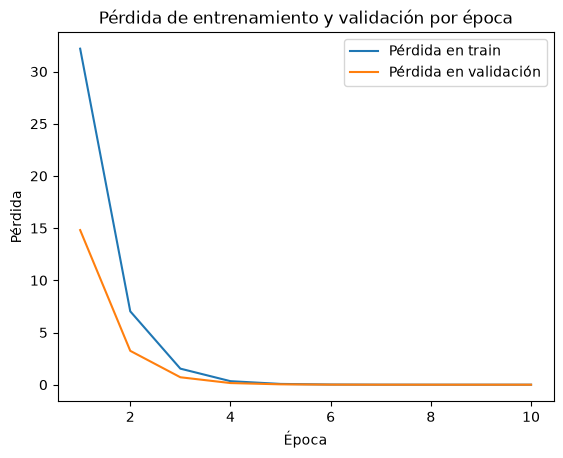

In [18]:
import matplotlib.pyplot as plt

# TODO: error en w y b, y gráfica de train/val loss por época

plt.plot(range(1, num_epochs + 1), train_losses, label = "Pérdida en train")
plt.plot(range(1, num_epochs + 1), val_losses, label = "Pérdida en validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.title("Pérdida de entrenamiento y validación por época")
plt.show()

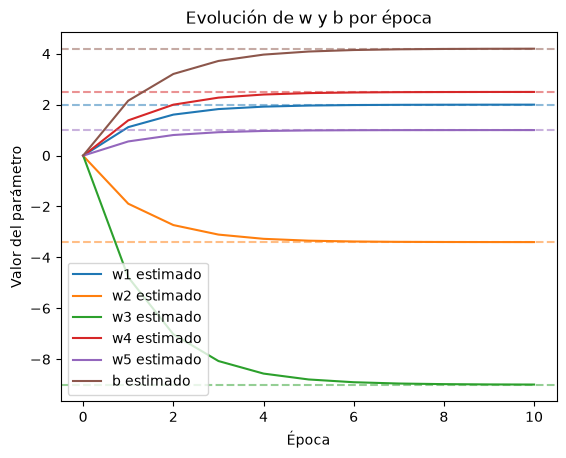

In [19]:
import torch

w_history_t = torch.stack(w_historico)  # forma (num_epochs, num_inputs)
num_inputs = w_history_t.shape[1]

# líneas de referencia con los valores verdaderos

for i in range(num_inputs):
    color =  f"C{i}"
    plt.plot(range(0, num_epochs + 1), w_history_t[:, i], color = color, label = f"w{i+1} estimado")
    plt.axhline(true_w[i].item(), color = color, linestyle = "--", alpha = 0.5)

b_color = f"C{num_inputs}"
plt.plot(range(0, num_epochs +1), b_historico, color = b_color, label = "b estimado")
plt.axhline(true_b, color = b_color, linestyle = "--", alpha = 0.5)

plt.xlabel("Época")
plt.ylabel("Valor del parámetro")
plt.legend()
plt.title("Evolución de w y b por época")
plt.show()


## 8. Experimentos (opcional)

Rompe cosas a propósito y anota qué pasa:
- Quitar `zero_grad()`
- `lr = 1.0` y `lr = 0.0001`
- Quitar `shuffle=True`

In [57]:
# Experimentación

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

In [58]:
model = LinearRegression(num_inputs = X.shape[1], lr = 0.03)
optim = model.configure_optimizers()

num_epochs = 10

train_losses, val_losses = [], []
w_historico, b_historico = [], []

w_historico.append(model.w.detach().clone().reshape(-1))
b_historico.append(model.b.item())

for epoch in range(1, num_epochs + 1):
    model.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader:
        y_hat = model(Xb)
        loss = model.loss(y_hat, yb)
        optim.zero_grad()
        loss.backward()
        optim.step()

        total_train += loss.item() * yb.shape[0]

        count_train += yb.shape[0]

    train_losses.append(total_train / count_train)

    # Validación 
    
    model.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = model.loss(model(Xv), yv)
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]
        
    val_losses.append(total_val / count_val)

    # Guardar el estado de w y b al final de cada época. 
    # Uso model.w.detach() para desenganchar w del grafo de gradientes y así guardar únicamente 
    # el valor numérico. 
    # .clone es necesario
    # .reshape(-1) lo deja como vector plano, más cómodo para graficar. 
    # .item() en b porque es un tensor de un solo elemento y sólo quiero el número
    w_historico.append(model.w.detach().clone().reshape(-1))
    b_historico.append(model.b.item())

with torch.no_grad():
    estimated_w = model.w.reshape(true_w.shape)
    estimated_b = model.b 

    print("Error en w: ", true_w - estimated_w)
    print("Error en b: ", true_b - estimated_b)


Error en w:  tensor([ 0.0011, -0.0010, -0.0054,  0.0015, -0.0005])
Error en b:  tensor([0.0032])


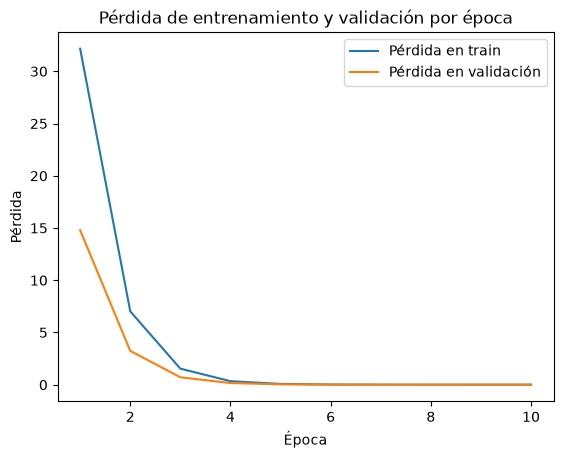

In [59]:
import matplotlib.pyplot as plt

# TODO: error en w y b, y gráfica de train/val loss por época

plt.plot(range(1, num_epochs + 1), train_losses, label = "Pérdida en train")
plt.plot(range(1, num_epochs + 1), val_losses, label = "Pérdida en validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.title("Pérdida de entrenamiento y validación por época")
plt.show()

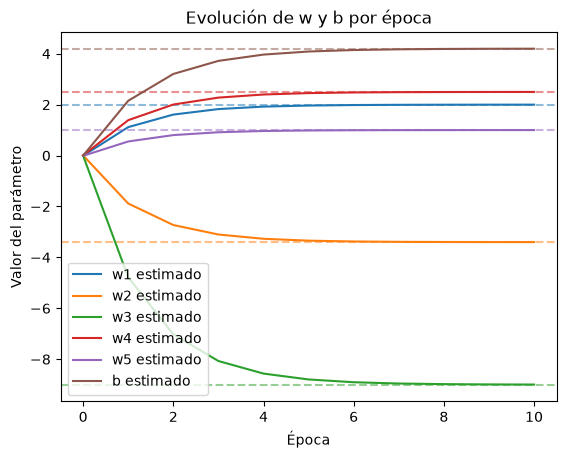

In [60]:
import torch

w_history_t = torch.stack(w_historico)  # forma (num_epochs, num_inputs)
num_inputs = w_history_t.shape[1]

# líneas de referencia con los valores verdaderos

for i in range(num_inputs):
    color =  f"C{i}"
    plt.plot(range(0, num_epochs + 1), w_history_t[:, i], color = color, label = f"w{i+1} estimado")
    plt.axhline(true_w[i].item(), color = color, linestyle = "--", alpha = 0.5)

b_color = f"C{num_inputs}"
plt.plot(range(0, num_epochs +1), b_historico, color = b_color, label = "b estimado")
plt.axhline(true_b, color = b_color, linestyle = "--", alpha = 0.5)

plt.xlabel("Época")
plt.ylabel("Valor del parámetro")
plt.legend()
plt.title("Evolución de w y b por época")
plt.show()